# Predict Future Stock Prices (Short-Term)

✔ Downloads historical stock data
✔ Uses OHLC + Volume as features
✔ Predicts next day's closing price
✔ Trains ML model
✔ Compares actual vs predicted visually

In [2]:
# Install if needed
!pip install yfinance scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyppeteer 2.0.0 requires pyee<12.0.0,>=11.0.0, but you have pyee 13.0.0 which is incompatible.
pyppeteer 2.0.0 requires websockets<11.0,>=10.0, but you have websockets 16.0 which is incompatible.


In [3]:
# Select stock ticker (AAPL for Apple)
ticker = "AAPL"

# Download historical data (last 5 years)
df = yf.download(ticker, start="2019-01-01", end="2024-01-01")

# Display basic info
print("Shape:", df.shape)
print(df.head())

[*********************100%***********************]  1 of 1 completed

Shape: (1258, 5)
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.503716  37.724579  36.627393  36.784135  148158800
2019-01-03  33.768066  34.606390  33.722944  34.193164  365248800
2019-01-04  35.209610  35.278483  34.150426  34.323790  234428400
2019-01-07  35.131252  35.344992  34.649157  35.314117  219111200
2019-01-08  35.800957  36.055068  35.271365  35.518348  164101200


In [4]:
# Create target column (Next Day Close)
df["Next_Close"] = df["Close"].shift(-1)

# Drop last row (NaN target)
df = df.dropna()

# Features and target
X = df[["Open", "High", "Low", "Volume"]]
y = df["Next_Close"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [7]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 5.412582767781701
R² Score: 0.9825884667082789


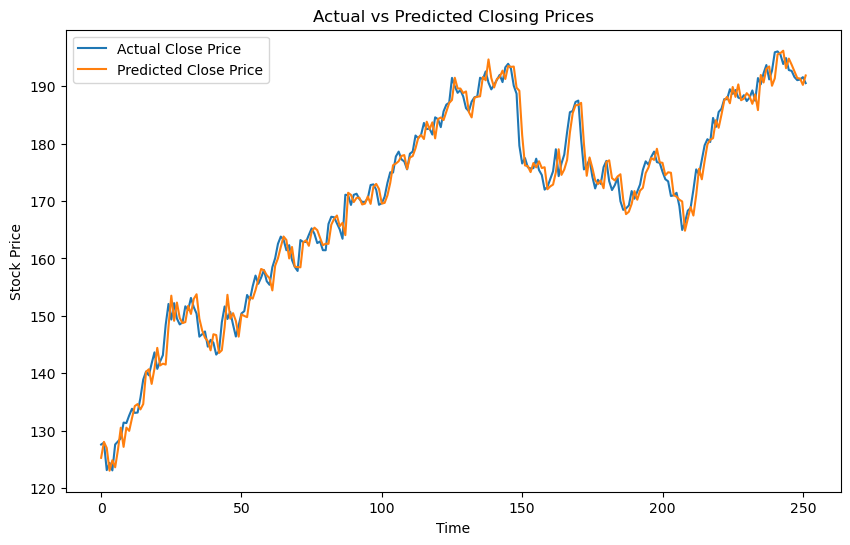

In [8]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual Close Price")
plt.plot(y_pred, label="Predicted Close Price")
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [9]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

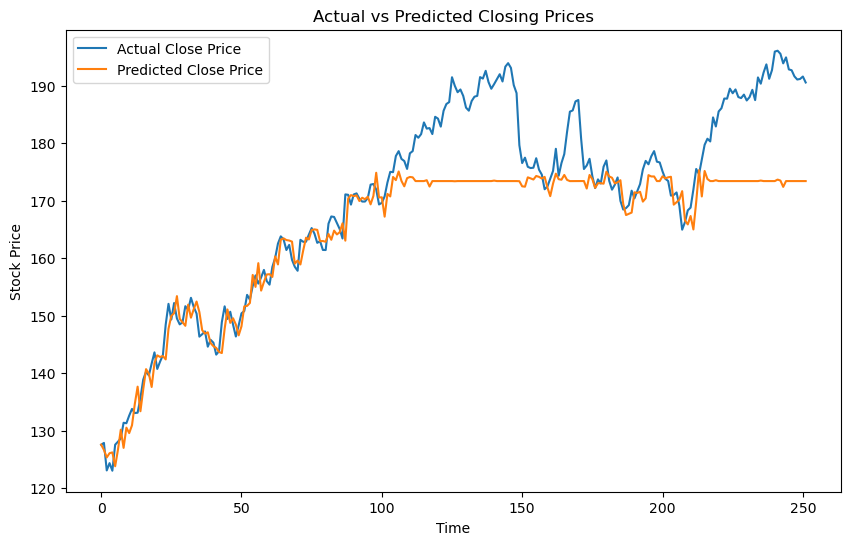

In [10]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual Close Price")
plt.plot(y_pred, label="Predicted Close Price")
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()